<a href="https://colab.research.google.com/github/00CARLOSECG00/SEKIA/blob/main/SEKIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerias

In [ ]:
# ── Dependencias base ──────────────────────────────────────────────────────────
!pip install -q faiss-cpu sentence-transformers chromadb pymupdf

# ── Análisis semántico ─────────────────────────────────────────────────────────
!pip install -q bertopic umap-learn hdbscan networkx spacy plotly

# ── RAG avanzado ───────────────────────────────────────────────────────────────
!pip install -q langchain langchain-community langchain-huggingface langchain-text-splitters
!pip install -q llama-index llama-index-embeddings-huggingface
!pip install -q sentence-transformers
!pip install -q ragas datasets

# ── Modelo de spaCy en español ─────────────────────────────────────────────────
!python -m spacy download es_core_news_sm

# ── GroqCloud -----------------─────────────────────────────────────────────────
!pip install transformers sentencepiece -q
!pip install anthropic -q
!pip install groq -q



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60

In [ ]:
# ── NLP clásico ────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud

# ── PDF y utilidades ───────────────────────────────────────────────────────────
import fitz  # PyMuPDF
from google.colab import files
import io, time, requests
import os

# ── Embeddings y bases vectoriales ─────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
import faiss
import chromadb
import shutil

# ── Análisis de temas (BERTopic) ───────────────────────────────────────────────
from bertopic import BERTopic
from umap import UMAP
import hdbscan
import re

# ── Entidades y grafos ─────────────────────────────────────────────────────────
import spacy
import networkx as nx

# ── Visualización ──────────────────────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA


# ── RAG: LangChain ─────────────────────────────────────────────────────────────
# En LangChain >= 0.2 los splitters viven en langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter  # fallback < 0.2

try:
    from langchain_community.vectorstores import Chroma
except ImportError:
    from langchain.vectorstores import Chroma

try:
    from langchain_huggingface import HuggingFaceEmbeddings
except ImportError:
    from langchain.embeddings import HuggingFaceEmbeddings

# ── RAG: LlamaIndex ────────────────────────────────────────────────────────────
try:
    from llama_index.core import VectorStoreIndex, Document, Settings
    from llama_index.embeddings.huggingface import HuggingFaceEmbedding
    LLAMA_OK = True
except ImportError:
    LLAMA_OK = False

# ── Cross-encoder (Re-ranking) ─────────────────────────────────────────────────
from sentence_transformers import CrossEncoder

# ── Evaluación RAGAS ───────────────────────────────────────────────────────────
try:
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
    from datasets import Dataset
    RAGAS_OK = True
except ImportError:
    RAGAS_OK = False

# ── Transformers (generación de respuestas) ────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# ── grouqCloud ------───────────────────────────────────────────────────────────
import anthropic
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from groq import Groq
# ── Ocultar key -----───────────────────────────────────────────────────────────
from google.colab import userdata
from groq import Groq

# ── Descargas NLTK ─────────────────────────────────────────────────────────────
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('spanish'))

print("Todas las librerías importadas correctamente")

/tmp/ipykernel_16334/2799680466.py:71: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_16334/2799680466.py:71: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_16334/2799680466.py:71: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import fait

Todas las librerías importadas correctamente


# Carga de información

In [ ]:
# ── Carpeta donde están los PDFs ──────────────────────────────────────────────
carpeta = "propuestas"

# ── Listar PDFs ───────────────────────────────────────────────────────────────
archivos_pdf = [f for f in os.listdir(carpeta) if f.endswith(".pdf")]

if not archivos_pdf:
    print("No se encontraron PDFs en la carpeta.")
else:
    print("Archivos disponibles:\n")

    for i, nombre in enumerate(archivos_pdf, start=1):
        print(f"{i}. {nombre}")

    # ── Elegir archivo ──────────────────────────────────────────────────────────
    opcion = int(input("\nEscribe el número del archivo que quieres leer: "))

    # Validación básica
    if opcion < 1 or opcion > len(archivos_pdf):
        print("Opción inválida.")
    else:
        nombre_archivo = archivos_pdf[opcion - 1]
        ruta = os.path.join(carpeta, nombre_archivo)

        doc = fitz.open(ruta)
        texto_completo = ""

        for pagina in doc:
            texto_completo += pagina.get_text()

        print(f"\nArchivo: {nombre_archivo}")
        print(f"Total caracteres extraídos: {len(texto_completo):,}")
        print("\n--- Primeros 500 chars ---")
        print(texto_completo[:500])

FileNotFoundError: [Errno 2] No such file or directory: 'propuestas'

In [ ]:
# ── Crear carpeta "propuestas" si no existe ───────────────────────────────────
os.makedirs("propuestas", exist_ok=True)

# ── Subir PDF desde tu computador ─────────────────────────────────────────────
uploaded = files.upload()

# ── Obtener nombre y contenido ────────────────────────────────────────────────
nombre_archivo = list(uploaded.keys())[0]
pdf_bytes = uploaded[nombre_archivo]

# ── Guardar archivo en la carpeta propuestas ───────────────────────────────────
ruta_guardado = os.path.join("propuestas", nombre_archivo)

with open(ruta_guardado, "wb") as f:
    f.write(pdf_bytes)

# ── Abrir el PDF desde el archivo guardado ────────────────────────────────────
doc = fitz.open(ruta_guardado)

texto_completo = ""
for pagina in doc:
    texto_completo += pagina.get_text()

print(f"Archivo: {nombre_archivo}")
print(f"Guardado en: {ruta_guardado}")
print(f"Total caracteres extraídos: {len(texto_completo):,}")
print("\n--- Primeros 500 chars ---")
print(texto_completo[:500])

Saving programa-gobierno-2026-2030.pdf to programa-gobierno-2026-2030.pdf
Archivo: programa-gobierno-2026-2030.pdf
Guardado en: propuestas/programa-gobierno-2026-2030.pdf
Total caracteres extraídos: 717,027

--- Primeros 500 chars ---
PROGRAMA DE 
GOBIERNO
2026-2030
PROGRAMA DE GOBIERNO 
DE IVÁN CEPEDA
2 0 2 6 - 2 0 3 0
Campaña PRESIDENCIAL
El Poder de la Verdad
PROGRAMA DE GOBIERNO  
DE IVÁN CEPEDA CASTRO
| 2 |
© Iván Cepeda Castro (de los textos)
Coordinación editorial 
Iván Cepeda Castro
Diseño y diagramación editorial
Diana Carolina Barón Jaime
Andrea Julieth Castellanos Leal
Foto portada
Javier De La Cuadra
@eljavidelacuadra
Fotografías
Nelsón Cárdenas Ferreira
@cantarranasur
Primera edición: marzo de 2026 Bogotá, D. C.,


# Nube de palabras

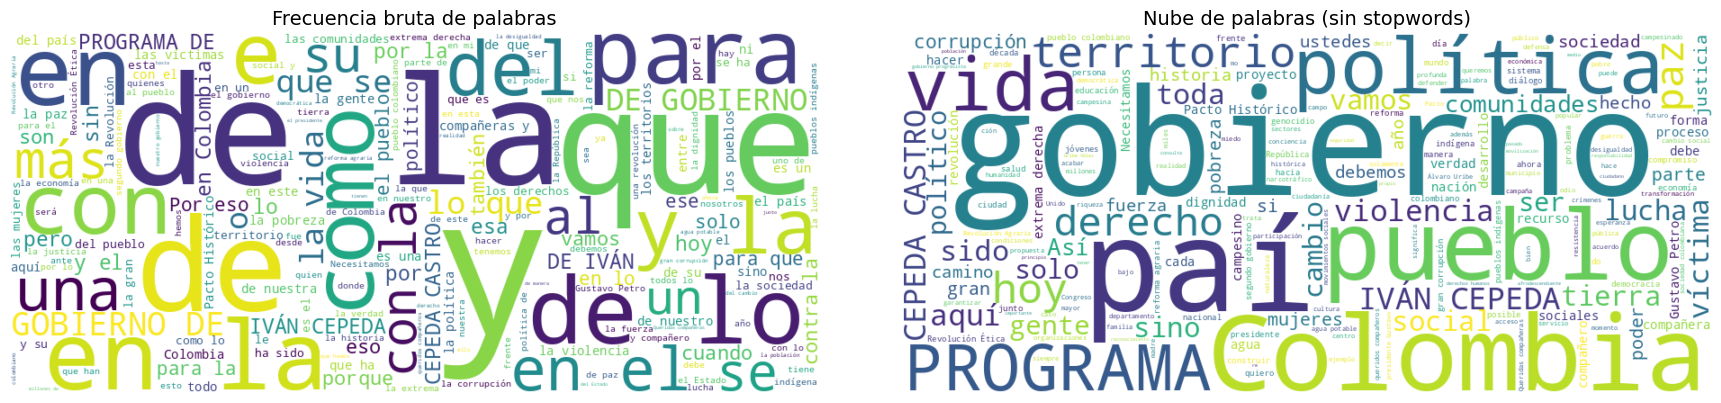

In [ ]:
# ── Nube de palabras sin filtro ────────────────────────────────────────────────
wordcloud_bruta = WordCloud(width=900, height=400, background_color="white").generate(texto_completo)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

axes[0].imshow(wordcloud_bruta, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Frecuencia bruta de palabras", fontsize=14)

# ── Nube filtrada (sin stopwords) ──────────────────────────────────────────────
wordcloud_filtrada = WordCloud(
    width=900, height=400,
    background_color="white",
    stopwords=stop_words
).generate(texto_completo)

axes[1].imshow(wordcloud_filtrada, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Nube de palabras (sin stopwords)", fontsize=14)

plt.tight_layout()
plt.show()

# Tokenizar con LangChain


In [ ]:
def limpiar_texto_base(texto):
    texto = re.sub(r"\|\s*\d+\s*\|", "", texto)  # | 114 |
    texto = re.sub(r"\n+", "\n", texto)          # saltos excesivos
    texto = re.sub(r"\s+", " ", texto)           # espacios múltiples
    return texto.strip()

In [ ]:
texto_completo = limpiar_texto_base(texto_completo)

In [ ]:
# =========================
# 3. Chunking híbrido
# =========================

# 👇 ESTA LÍNEA FALTABA
splitter_lc = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

parrafos = texto_completo.split("\n\n")
chunks = []

for p in parrafos:
    p = p.strip()
    if len(p) < 50:
        continue
    if len(p) > 450:
        subchunks = splitter_lc.split_text(p)
        chunks.extend(subchunks)
    else:
        chunks.append(p)

print(f"Chunks finales: {len(chunks)}")

Chunks finales: 2088


# Generación de embeddings + Carga DB

In [ ]:
# =========================
# 0. BORRAR DB VIEJA (forzado)
# =========================
shutil.rmtree("./chroma_db", ignore_errors=True)
os.makedirs("./chroma_db", exist_ok=True)

# =========================
# 1. Modelo embeddings
# =========================
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# =========================
# 2. Cliente Chroma
# =========================
cliente = chromadb.PersistentClient(path="./chroma_db")

coleccion = cliente.get_or_create_collection(
    name="pdf_programa_gobierno",
    metadata={"hnsw:space": "cosine"}
)

# =========================
# 3. Embeddings
# =========================
embeddings = model.encode(chunks, show_progress_bar=True).tolist()



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/66 [00:00<?, ?it/s]

In [ ]:
# =========================
# 4. Insertar con metadatos
# =========================
coleccion.add(
    documents=chunks,
    embeddings=embeddings,
    ids=[f"id_{i}" for i in range(len(chunks))],
    metadatas=[{"pagina": str(i)} for i in range(len(chunks))]
)

print(f"Insertados {coleccion.count()} chunks en ChromaDB")

Insertados 2088 chunks en ChromaDB


# Visualización embeddings

In [ ]:
embeddings_np = np.array(embeddings)
# ── Reducción UMAP ─────────────────────────────────────────────────────────────
reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
emb_umap = reducer.fit_transform(embeddings_np)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=emb_umap[:, 0], y=emb_umap[:, 1],
    mode="markers",
    marker=dict(color=list(range(len(chunks))), colorscale="Plasma", size=5, opacity=0.7),
    name="UMAP",
    hovertext=[f"Chunk {i}: {c[:80]}..." for i, c in enumerate(chunks)]
))

fig2.update_layout(
    title="Visualización UMAP de Embeddings (estructura semántica)",
    xaxis_title="UMAP-1", yaxis_title="UMAP-2",
    height=500
)
fig2.show()

# Temas con BERTopic

In [ ]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\s+', ' ', texto)  # espacios raros
    texto = re.sub(r'[^\w\s]', '', texto)  # puntuación

    tokens = texto.split()
    tokens_limpios = [t for t in tokens if t not in stop_words]

    return " ".join(tokens_limpios)

In [ ]:
chunks_limpios = [limpiar_texto(c) for c in chunks]
# ── Configurar UMAP y HDBSCAN para BERTopic ────────────────────────────────────
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=max(5, len(chunks_limpios)//20),
                                  metric='euclidean', cluster_selection_method='eom',
                                  prediction_data=True)

# ── Entrenar BERTopic ──────────────────────────────────────────────────────────
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(chunks_limpios, embeddings_np)

# ── Resumen de temas ───────────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print(f"\nTemas encontrados: {len(topic_info) - 1} (excluyendo outliers)")
print("\nTop temas:")
print(topic_info[topic_info.Topic != -1].head(10).to_string(index=False))

# ── Visualización de temas ─────────────────────────────────────────────────────
try:
    fig_topics = topic_model.visualize_topics()
    fig_topics.show()
    fig_barchart = topic_model.visualize_barchart(top_n_topics=8)
    fig_barchart.show()
except Exception as e:
    print(f"Visualización disponible en entorno con GPU: {e}")

# Guardar asignación de temas
df_topics = pd.DataFrame({"chunk": chunks_limpios, "topic": topics})
print(f"\nTemas asignados. Distribución:\n{df_topics.topic.value_counts().head()}")

2026-05-04 21:22:38,474 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 21:22:50,114 - BERTopic - Dimensionality - Completed ✓
2026-05-04 21:22:50,116 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 21:22:50,333 - BERTopic - Cluster - Completed ✓
2026-05-04 21:22:50,347 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 21:22:50,455 - BERTopic - Representation - Completed ✓



Temas encontrados: 2 (excluyendo outliers)

Top temas:
 Topic  Count                              Name                                                                        Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

# Reconocer entidades con spaCy

In [ ]:
# ── Cargar modelo spaCy en español ────────────────────────────────────────────
nlp = spacy.load("es_core_news_sm")

# ── Extraer entidades de los primeros 50 chunks ────────────────────────────────
entidades_lista = []
MAX_CHUNKS_NER = min(50, len(chunks))

for i, chunk in enumerate(chunks[:MAX_CHUNKS_NER]):
    doc_spacy = nlp(chunk[:1000])  # limitar largo para velocidad
    for ent in doc_spacy.ents:
        entidades_lista.append({
            "texto": ent.text,
            "tipo": ent.label_,
            "chunk_id": i,
            "descripcion": spacy.explain(ent.label_)
        })

df_entidades = pd.DataFrame(entidades_lista)

if not df_entidades.empty:
    print(f"Entidades extraídas: {len(df_entidades)}")
    print(f"Tipos únicos: {df_entidades.tipo.unique()}")
    print("\nTop entidades por frecuencia:")
    print(df_entidades.groupby(["texto", "tipo"]).size()
          .sort_values(ascending=False).head(15).to_string())

    # ── Gráfica de distribución de tipos ──────────────────────────────────────
    tipo_counts = df_entidades.tipo.value_counts()
    fig_ner = px.bar(
        x=tipo_counts.index, y=tipo_counts.values,
        labels={"x": "Tipo de entidad", "y": "Frecuencia"},
        title="Distribución de tipos de entidades (spaCy NER)",
        color=tipo_counts.values, color_continuous_scale="Blues"
    )
    fig_ner.show()
else:
    print("No se encontraron entidades. Verifica el idioma del documento.")

Entidades extraídas: 226
Tipos únicos: ['ORG' 'MISC' 'PER' 'LOC']

Top entidades por frecuencia:
texto               tipo
IVÁN                MISC    15
GOBIERNO            ORG      7
PROGRAMA            ORG      6
Colombia            LOC      5
Pacto Histórico     MISC     4
CASTRO              ORG      4
DESARROLLO          MISC     3
FORMA               ORG      2
DEFENSA             MISC     2
PACTO               ORG      2
POLÍTICA            ORG      2
JUNTOS              ORG      2
PRESENTAR           MISC     2
REVOLUCIÓN AGRARIA  MISC     2
TERRITORIOS         MISC     2


## Grafo entidades

Nodos totales: 170
Aristas totales: 615
Nodos filtrados (grado ≥ 2): 155

🏆 Top nodos por centralidad:
  IVÁN                           → 0.3182
  PROGRAMA                       → 0.1948
  GOBIERNO                       → 0.1753
  CASTRO                         → 0.1429
  DESARROLLO                     → 0.1169
  TERRITORIOS                    → 0.1104
  PRESENTAR                      → 0.0974
  JUNTOS                         → 0.0974
  FORMA                          → 0.0974
  POLÍTICA                       → 0.0974


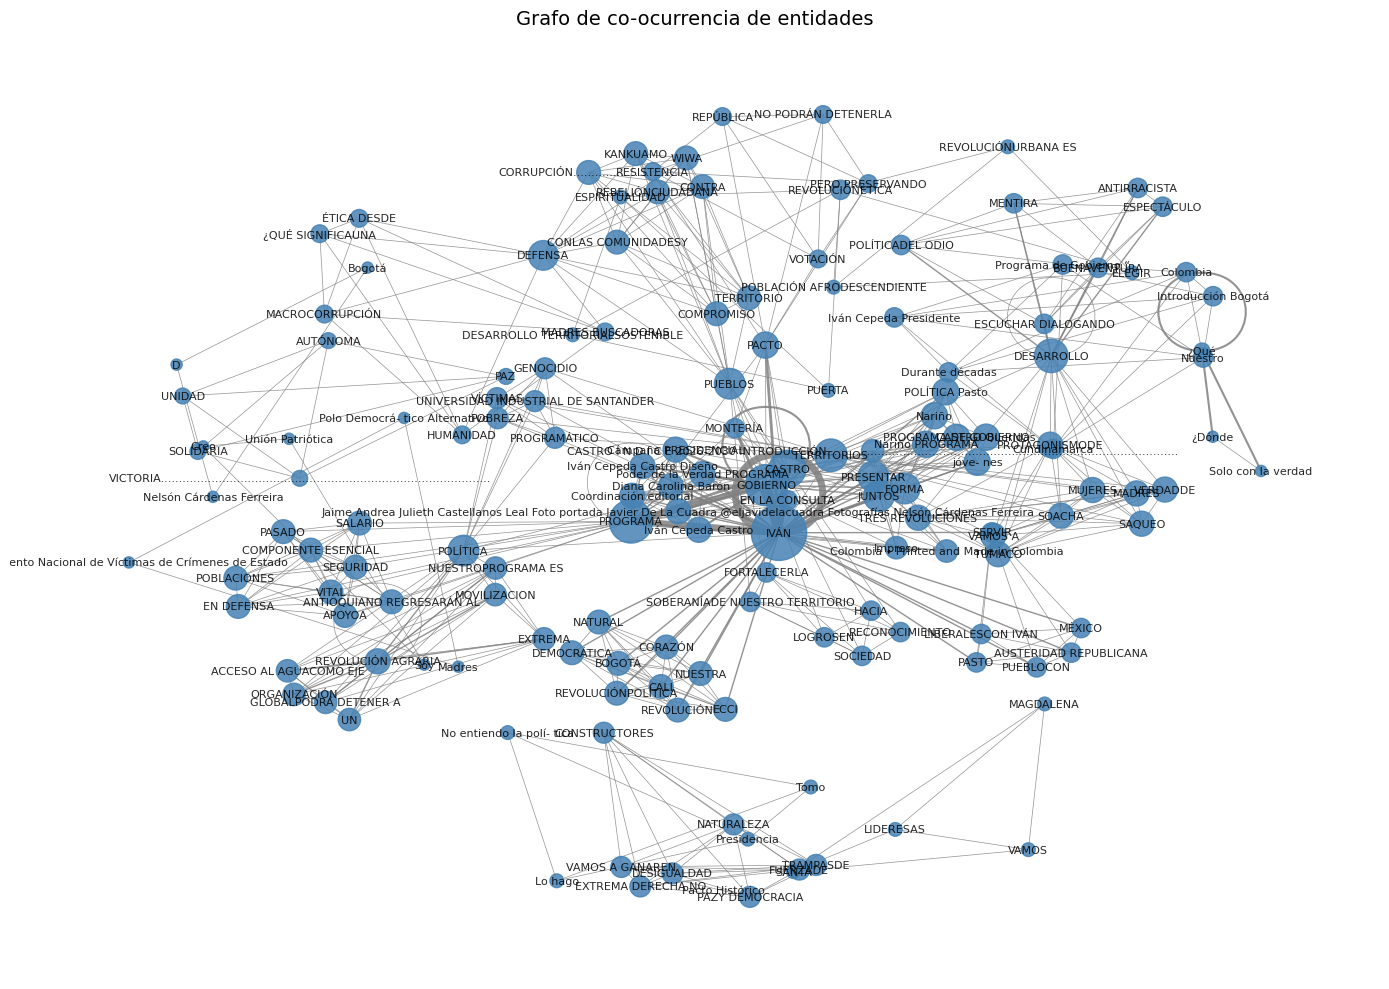

In [ ]:
# ── Construir grafo de co-ocurrencia ───────────────────────────────────────────
G = nx.Graph()

if not df_entidades.empty:
    for chunk_id, grupo in df_entidades.groupby("chunk_id"):
        entidades_chunk = grupo["texto"].tolist()
        # Crear aristas entre pares de entidades del mismo chunk
        for i in range(len(entidades_chunk)):
            for j in range(i+1, len(entidades_chunk)):
                ent_a, ent_b = entidades_chunk[i], entidades_chunk[j]
                if G.has_edge(ent_a, ent_b):
                    G[ent_a][ent_b]["weight"] += 1
                else:
                    G.add_edge(ent_a, ent_b, weight=1)

    # ── Filtrar nodos poco conectados ─────────────────────────────────────────
    grado_minimo = 2
    nodos_relevantes = [n for n, d in G.degree() if d >= grado_minimo]
    G_filtrado = G.subgraph(nodos_relevantes)

    print(f"Nodos totales: {G.number_of_nodes()}")
    print(f"Aristas totales: {G.number_of_edges()}")
    print(f"Nodos filtrados (grado ≥ {grado_minimo}): {G_filtrado.number_of_nodes()}")

    # ── Centralidad de grado ───────────────────────────────────────────────────
    centralidad = nx.degree_centrality(G_filtrado)
    top_nodos = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\n🏆 Top nodos por centralidad:")
    for nodo, cent in top_nodos:
        print(f"  {nodo:30s} → {cent:.4f}")

    # ── Visualización con matplotlib ───────────────────────────────────────────
    if G_filtrado.number_of_nodes() > 0:
        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(G_filtrado, k=0.5, seed=42)
        pesos = [G_filtrado[u][v].get("weight", 1) for u, v in G_filtrado.edges()]
        nx.draw_networkx(
            G_filtrado, pos,
            node_size=[centralidad.get(n, 0.01) * 5000 for n in G_filtrado.nodes()],
            edge_color="gray", width=[w*0.5 for w in pesos],
            font_size=8, node_color="steelblue", alpha=0.85, with_labels=True
        )
        plt.title("Grafo de co-ocurrencia de entidades", fontsize=14)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("No hay entidades para construir el grafo.")

# Consulta DB Vectorial

In [ ]:
# ── Consulta semántica interactiva ────────────────────────────────────────────
consulta = input("Consulta: ")
n_resultados = int(input("# de respuestas: ") or "5")

embedding_q = model.encode([consulta]).tolist()
resultados = coleccion.query(
    query_embeddings=embedding_q,
    n_results=n_resultados,
    include=["documents", "distances", "metadatas"]
)

print(f"\nConsulta: '{consulta}'")
print("\n--- Resultados más relevantes ---")
for i, (doc, dist) in enumerate(zip(resultados["documents"][0], resultados["distances"][0])):
    print(f"\n[{i+1}] Similitud: {1 - dist:.4f}")

    # 👇 FIX: proteger contra metadatos None
    meta = resultados['metadatas'][0][i]
    pagina = meta.get('pagina', 'N/A') if meta else 'N/A'
    print(f"     Página: {pagina}")
    print(f"     {doc[:300]}")

Consulta: Educación
# de respuestas: 28

Consulta: 'Educación'

--- Resultados más relevantes ---

[1] Similitud: 0.5318
     Página: 635
     . Esa es Gilma Gómez. Gilma ha hecho de la educación no solamente un motivo para movilizarse y para hacer lucha social y política, sino ha hecho sobre todo de la educación un sentido de vida. Es una educadora en todo el sentido de la palabra. En la educación formal y en la vida social, que es tan im

[2] Similitud: 0.5121
     Página: 349
     surjan profesionales esté al servicio de lo más importante hoy: las comunidades y el pueblo que nunca han tenido acceso a una educación de calidad

[3] Similitud: 0.4915
     Página: 1887
     . El camino de brindar a la juventud la posibilidad de la educación, incluida, la educación superior en zonas rurales, que hasta ahora han sido excluidas de la universidad pública, la educación que debe permitir empleos dignos, para contrarrestar el reclutamiento forzado y las redes del narcotráfico

[4] Similitud: 0

# Respuesta

In [ ]:
api_key = userdata.get("my-secret-key")

groq_client = Groq(api_key=api_key)
# =========================
# 4. Preparar fragmentos
# =========================

docs_filtrados = resultados["documents"][0]

if not docs_filtrados:
    print("No hay contexto suficientemente relevante")
else:
    fragmentos = "\n\n".join(docs_filtrados)

    prompt = f"""Eres un asistente que analiza propuestas políticas en Colombia de forma precisa y neutral.

Responde la consulta usando SOLO los fragmentos recuperados. No inventes información.
 solo realiza una calificacion desde los objetivos SMART para esa propuesta, dandole puntaje a cada letra.
Si la información es insuficiente, responde: "No hay información suficiente."
pero usa todos los fragmentos disponibles (siempre y cuando exista conección lógica con la consulta)

Consulta:
{consulta}

Fragmentos recuperados:
{fragmentos}

Resumen:"""

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0.3
    )

    print("\nResumen generado:\n")
    print(response.choices[0].message.content)


Resumen generado:

Calificación de la propuesta de educación según los objetivos SMART:

**S** (Específico): 8/10 - La propuesta se enfoca en mejorar la educación en Colombia, especialmente en zonas rurales y para poblaciones marginadas, pero no se especifican metas claras y medibles.

**M** (Medible): 6/10 - No se proporcionan indicadores concretos para medir el progreso o el éxito de la propuesta, como por ejemplo, el aumento en la matrícula escolar o la mejora en los resultados académicos.

**A** (Asequible): 7/10 - La propuesta parece factible, ya que se menciona la creación de universidades y programas de educación en zonas rurales, pero no se proporcionan detalles sobre los recursos necesarios para implementarla.

**R** (Relevante): 9/10 - La educación es un tema crucial en Colombia, y la propuesta se enfoca en mejorar la educación en zonas marginadas, lo que es relevante para el desarrollo del país.

**T** (Temporal): 5/10 - No se proporciona un cronograma claro para la impleme